# TimeEvolver Python Binding Example

This notebook demonstrates the new `timeevolver` Python binding on a simple two-level system.

In [59]:
import math
import pathlib
import sys

import numpy as np

module_dir = None
for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    candidate = base / "build" / "python"
    if candidate.exists():
        module_dir = candidate
        break

if module_dir is None:
    raise FileNotFoundError("Could not locate build/python with the timeevolver module.")

sys.path.insert(0, str(module_dir))

import timeevolver

print("Using module from:", module_dir)
print(timeevolver.__doc__)

Using module from: /home/ann/dev/TimeEvolver/build/python
Python bindings for TimeEvolver core Krylov time evolution


## Helper: dense matrix to `SparseMatrix`

`SparseMatrix` expects triplets `(value, column, row_index)` for each non-zero element.

In [60]:
def dense_to_sparse_matrix(a, *, sym=False, hermitian=False, upper_tri=False, tol=1.0e-14):
    a = np.asarray(a, dtype=np.complex128)
    if a.ndim != 2:
        raise ValueError("Input matrix must be 2D")

    n, m = a.shape
    values = []
    columns = []
    row_index = []

    for row in range(n):
        for col in range(m):
            val = a[row, col]
            if abs(val) > tol:
                values.append(complex(val))
                columns.append(col)
                row_index.append(row)

    return timeevolver.SparseMatrix(
        n=n,
        m=m,
        values=values,
        columns=columns,
        row_index=row_index,
        sym=sym,
        hermitian=hermitian,
        upper_tri=upper_tri,
    )

## Build a 2-level model

We use `H = [[0, 1], [1, 0]]` (Pauli-X), initial state `|0>`, and sample projector observables `P0`, `P1`.

In [61]:
H_dense = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=np.complex128)
P0_dense = np.array([[1.0, 0.0], [0.0, 0.0]], dtype=np.complex128)
P1_dense = np.array([[0.0, 0.0], [0.0, 1.0]], dtype=np.complex128)

H = dense_to_sparse_matrix(H_dense, sym=True, hermitian=True)
P0 = dense_to_sparse_matrix(P0_dense, hermitian=True)
P1 = dense_to_sparse_matrix(P1_dense, hermitian=True)

observables = [
    timeevolver.SpMatrixObservable("P0", P0),
    timeevolver.SpMatrixObservable("P1", P1),
]

initial_state = [1.0 + 0.0j, 0.0 + 0.0j]
t_final = math.pi
sampling_step = math.pi / 32

## Run with function API

In [62]:
result_fn = timeevolver.time_evolve(
    t=t_final,
    initial_state=initial_state,
    sampling_step=sampling_step,
    hamiltonian=H,
    observables=observables,
    tol=1.0e-10,
    m=4,
    progress_bar=False,
)

print("status_code:", result_fn.status_code)
print("evolved_time:", result_fn.evolved_time)
print("num_samples:", result_fn.num_samples)
print("observable_names:", result_fn.observable_names)
print("final_state:", result_fn.evolved_state)

status_code: 1
evolved_time: 3.141592653589793
num_samples: 33
observable_names: ['P0', 'P1']
final_state: [(-0.9999999999999998+4.550362512932902e-16j), (-1.6653345369377348e-16+1.4579848346013136e-15j)]
[2026-02-24 18:53:43.976845] [0x00007f9e38ced300] [info]    ***Lucky breakdown at Krylov dimension2 *** 
[2026-02-24 18:53:43.976928] [0x00007f9e38ced300] [warning] Warning: Analytic error 0 was smaller than the estimate of the numerical error 4.44089e-16. 				The computed error is not accurate.


## Run with class API and compare

In [63]:
evolver = timeevolver.TimeEvolver(
    t=t_final,
    initial_state=initial_state,
    sampling_step=sampling_step,
    hamiltonian=H,
    observables=observables,
    tol=1.0e-10,
    m=4,
)
result_cls = evolver.time_evolve()

max_state_diff = max(abs(a - b) for a, b in zip(result_fn.evolved_state, result_cls.evolved_state))
print("max |state_fn - state_cls| =", max_state_diff)

max |state_fn - state_cls| = 0.0
[2026-02-24 18:53:43.988955] [0x00007f9e38ced300] [info]    ***Lucky breakdown at Krylov dimension2 *** 
[2026-02-24 18:53:43.989012] [0x00007f9e38ced300] [warning] Warning: Analytic error 0 was smaller than the estimate of the numerical error 4.44089e-16. 				The computed error is not accurate.


## Compare with analytic two-level solution

First 5 <P0>(t): [1.         0.99039264 0.96193977 0.91573481 0.85355339]
First 5 <P1>(t): [0.         0.00960736 0.03806023 0.08426519 0.14644661]
Max |<P0>_num - <P0>_analytic|: 7.771561172376096e-16
Max |<P1>_num - <P1>_analytic|: 1.1102230246251565e-15
Max |psi_num(t_final) - psi_analytic(t_final)|: 1.589199187997902e-15


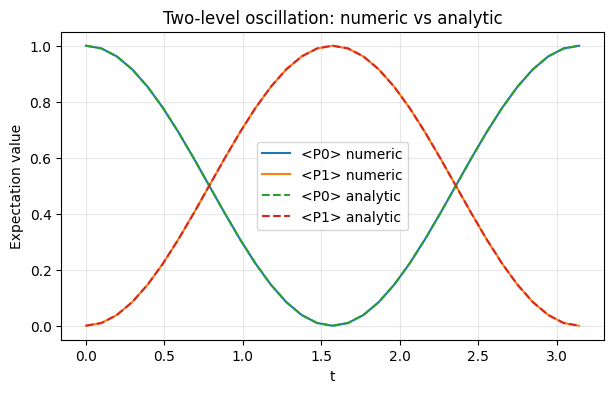

In [64]:
times = np.linspace(0.0, result_fn.evolved_time, result_fn.num_samples)
obs_map = {name: np.array(vals) for name, vals in zip(result_fn.observable_names, result_fn.observable_values)}

# For H = sigma_x and |psi(0)> = |0>, we have |psi(t)> = cos(t)|0> - i sin(t)|1>.
p0_analytic = np.cos(times) ** 2
p1_analytic = np.sin(times) ** 2
state_analytic_final = np.array([
    np.cos(result_fn.evolved_time),
    -1j * np.sin(result_fn.evolved_time),
], dtype=np.complex128)
state_numeric_final = np.array(result_fn.evolved_state, dtype=np.complex128)

max_err_p0 = np.max(np.abs(obs_map["P0"] - p0_analytic))
max_err_p1 = np.max(np.abs(obs_map["P1"] - p1_analytic))
max_err_state_final = np.max(np.abs(state_numeric_final - state_analytic_final))

print("First 5 <P0>(t):", obs_map["P0"][:5])
print("First 5 <P1>(t):", obs_map["P1"][:5])
print("Max |<P0>_num - <P0>_analytic|:", max_err_p0)
print("Max |<P1>_num - <P1>_analytic|:", max_err_p1)
print("Max |psi_num(t_final) - psi_analytic(t_final)|:", max_err_state_final)

try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 4))
    plt.plot(times, obs_map["P0"], label="<P0> numeric")
    plt.plot(times, obs_map["P1"], label="<P1> numeric")
    plt.plot(times, p0_analytic, "--", label="<P0> analytic")
    plt.plot(times, p1_analytic, "--", label="<P1> analytic")
    plt.xlabel("t")
    plt.ylabel("Expectation value")
    plt.title("Two-level oscillation: numeric vs analytic")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
except ImportError:
    print("matplotlib not installed; skipping plot.")

## Optional: HDF5 round-trip for `SparseMatrix`

This works only if TimeEvolver was built with HDF5 support (`USE_HDF`).

In [65]:
hdf_path = pathlib.Path("output") / "python_binding_example_hamiltonian.h5"
hdf_path.parent.mkdir(parents=True, exist_ok=True)

try:
    H.save_hdf5(str(hdf_path))
    H_loaded = timeevolver.SparseMatrix.load_hdf5(str(hdf_path))
    print("Saved and reloaded HDF5 matrix:", hdf_path)
    print("loaded dimensions:", H_loaded.n, H_loaded.m)
except RuntimeError as exc:
    print("HDF5 support not available in this build:")
    print(exc)

Saved and reloaded HDF5 matrix: output/python_binding_example_hamiltonian.h5
loaded dimensions: 2 2


## Load C++ HDF5 exports (Hamiltonian + observables)

Place `BH_Hamiltonian.h5`, `BH_Observable*.h5`, and `BH_InitialStateIndex.txt` in `<repo>/output/`.

The code below loads those HDF5 matrices via the Python binding and reconstructs the same one-hot initial state index used by C++.


In [66]:
import pathlib
import re

def _find_cpp_output_dir(start_dir=None):
    start = pathlib.Path.cwd() if start_dir is None else pathlib.Path(start_dir)
    for base in [start, *start.parents]:
        candidate = (base / "output").resolve()
        if (candidate / "BH_Hamiltonian.h5").exists():
            return candidate
    raise FileNotFoundError("Could not find output/BH_Hamiltonian.h5.")

def _observable_index(path):
    m = re.search(r"(\d+)$", path.stem)
    if m is None:
        raise ValueError(f"Observable file has no trailing index: {path.name}")
    return int(m.group(1))

cpp_output_dir = _find_cpp_output_dir()
ham_path = cpp_output_dir / "BH_Hamiltonian.h5"
obs_paths = sorted(cpp_output_dir.glob("BH_Observable*.h5"), key=_observable_index)
if not obs_paths:
    raise FileNotFoundError(f"No BH_Observable*.h5 files found in {cpp_output_dir}")

H_cpp = timeevolver.SparseMatrix.load_hdf5(str(ham_path))

obs_cpp = []
skipped_obs = []
for i, path in enumerate(obs_paths):
    matrix = timeevolver.SparseMatrix.load_hdf5(str(path))
    if matrix.n != H_cpp.n or matrix.m != H_cpp.m:
        skipped_obs.append((path.name, matrix.n, matrix.m))
        continue
    obs_cpp.append(timeevolver.SpMatrixObservable(f"mode{len(obs_cpp)}", matrix))

if not obs_cpp:
    raise ValueError(
        f"No observable dimensions match Hamiltonian {H_cpp.n}x{H_cpp.m}."
    )

if skipped_obs:
    print("Skipped mismatched observables:")
    for name, n, m in skipped_obs:
        print(f"  - {name}: {n}x{m}")

idx_file = cpp_output_dir / "BH_InitialStateIndex.txt"
initial_state_cpp = [0.0 + 0.0j] * H_cpp.n
if idx_file.exists():
    initial_index = int(idx_file.read_text().strip())
    if initial_index < 0 or initial_index >= H_cpp.n:
        raise ValueError(
            f"Initial-state index {initial_index} is out of bounds for dimension {H_cpp.n}."
        )
else:
    initial_index = 0
    print("BH_InitialStateIndex.txt not found; falling back to initial index 0.")
initial_state_cpp[initial_index] = 1.0 + 0.0j

print("C++ output directory:", cpp_output_dir)
print("Hamiltonian dimension:", H_cpp.n, "x", H_cpp.m)
print("Observable files loaded:", len(obs_cpp))
print("Initial state basis index:", initial_index)


C++ output directory: /home/ann/dev/TimeEvolver/output
Hamiltonian dimension: 588 x 588
Observable files loaded: 10
Initial state basis index: 21


In [67]:
# Match defaults from example/main.cpp
max_t_cpp = 10.0
sampling_step_cpp = 0.01
tol_cpp = 1.0e-8
m_cpp = 40

result_cpp_hdf = timeevolver.time_evolve(
    t=max_t_cpp,
    initial_state=initial_state_cpp,
    sampling_step=sampling_step_cpp,
    hamiltonian=H_cpp,
    observables=obs_cpp,
    tol=tol_cpp,
    m=m_cpp,
    progress_bar=False,
)

print("status_code:", result_cpp_hdf.status_code)
print("num_samples:", result_cpp_hdf.num_samples)
print("num_observables:", len(result_cpp_hdf.observable_names))
print("first 5 samples of", result_cpp_hdf.observable_names[0], ":", result_cpp_hdf.observable_values[0][:5])


status_code: 0
num_samples: 1001
num_observables: 10
first 5 samples of mode0 : [20.000000000000004, 19.99800006999981, 19.99200111998761, 19.98200566985765, 19.96801791919088]


## Visualize C++ HDF5 evolution

These plots show mode occupations over time from the HDF5-loaded Hamiltonian and observables.


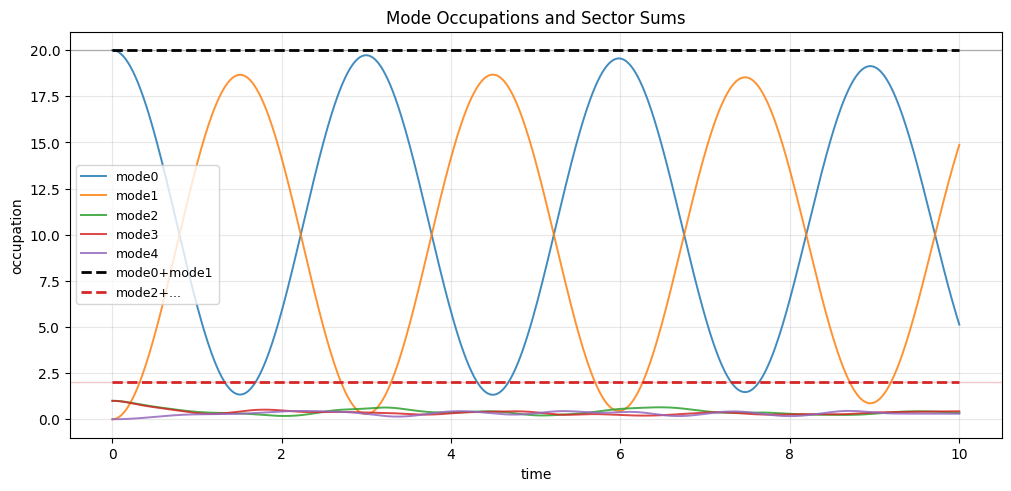

In [68]:
cpp_times = np.linspace(0.0, result_cpp_hdf.evolved_time, result_cpp_hdf.num_samples)
cpp_values = np.asarray(result_cpp_hdf.observable_values, dtype=float)
cpp_names = list(result_cpp_hdf.observable_names)

control_count = min(2, len(cpp_names))
control_occ = np.sum(cpp_values[:control_count], axis=0)
critical_occ = np.sum(cpp_values[2:], axis=0) if len(cpp_names) > 2 else np.zeros_like(cpp_times)

try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)

    # Plot selected individual modes for context
    max_lines = min(5, len(cpp_names))
    for i in range(max_lines):
        ax.plot(cpp_times, cpp_values[i], label=cpp_names[i], linewidth=1.4, alpha=0.85)

    # Plot conserved sectors
    ax.plot(
        cpp_times,
        control_occ,
        label="mode0+mode1",
        color="black",
        linestyle="--",
        linewidth=2.0,
    )
    ax.plot(
        cpp_times,
        critical_occ,
        label="mode2+...",
        color="tab:red",
        linestyle="--",
        linewidth=2.0,
    )

    ax.axhline(20.0, color="black", alpha=0.25, linewidth=1.0)
    ax.axhline(2.0, color="tab:red", alpha=0.25, linewidth=1.0)
    ax.set_title("Mode Occupations and Sector Sums")
    ax.set_xlabel("time")
    ax.set_ylabel("occupation")
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=9)

    plt.show()
except ImportError:
    print("matplotlib not installed; skipping visualization plots.")


## Optional: compare with C++ `ResultBlackHole_*.h5`

If `h5py` is installed and a C++ result file exists in `<repo>/output/`, this checks max absolute difference across all `mode{i}` datasets.


In [69]:
try:
    import h5py
except ImportError:
    print("h5py is not installed; skipping C++ result-file comparison.")
else:
    result_files = sorted(
        cpp_output_dir.glob("ResultBlackHole_*.h5"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not result_files:
        print("No ResultBlackHole_*.h5 found in", cpp_output_dir)
    else:
        ref_path = result_files[0]
        max_abs_diff = 0.0
        with h5py.File(ref_path, "r") as f:
            for i, values in enumerate(result_cpp_hdf.observable_values):
                dataset_name = f"mode{i}"
                if dataset_name not in f:
                    raise KeyError(f"Dataset {dataset_name} not found in {ref_path}")
                ref_values = np.asarray(f[dataset_name][...], dtype=float)
                py_values = np.asarray(values, dtype=float)
                if ref_values.shape != py_values.shape:
                    raise ValueError(
                        f"Shape mismatch for {dataset_name}: {ref_values.shape} vs {py_values.shape}"
                    )
                max_abs_diff = max(max_abs_diff, float(np.max(np.abs(ref_values - py_values))))
        print("Compared against:", ref_path.name)
        print("Max |Python - C++| across all modes:", max_abs_diff)


Compared against: ResultBlackHole_N20_Nm2_K4_C1_DeltaN12_C01_Cm1_maxT10_tol1e-08_samplingStep0.01_m40_fastIntegration0.h5
Max |Python - C++| across all modes: 2.3447910280083306e-13
